<a href="https://colab.research.google.com/github/Priyanshi07-ai/mobile_app_review_classify_ann_model/blob/main/ann_final1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROJECT NAME - MOBILE APP REVIEWS
CLASSIFIER**

**CONTRIBUTION - INDIVIDUAL NAME - PRIYANSHI BHANDARI**

***Summary: This project is basically about understanding user feedback from text and turning it into something useful using ANN(artificial neural networks).***

***It starts with a dataset of user reviews where each review has a score. the code first converts these scores into sentiment labels like negative neutral and positive. So instead of raw numbers it becomes easier for the model to learn how people feel about the app.***

***Then the text data is cleaned.Things like uppercase letters numbers and extra spaces are removed so the text becomes simple and consistent.After that some words are normalized for example words like design layout and interface are all treated as ui. this helps the model not get confused by different words that mean the same thing.***
***The project does two main things at once. first it predicts sentiment which tells if the review is positive neutral or negative. second it detects topics inside the review like bugs ui ux or ads. so instead of just knowing how a user feels it also understands what they are talking about.***
***There is also a small logic added for neutral words like okay or average. even if the score says something else the model adjusts sentiment to neutral if such words appear.This makes predictions feel more realistic.***
***After preprocessing the text is converted into numbers using tokenization and padding. this is needed because neural networks cannot understand raw text directly.***
***The model used is a neural network built with embedding and dense layers.It has two outputs one for sentiment and one for topics. this is called a multi output model because it solves two problems at the same time.***
***During training the model learns from both sentiment labels and topic labels together. topic prediction is treated as multi label which means one review can belong to multiple topics like bugs and ads at the same time.***
***After training the model can take a new review as input and return both the sentiment and the list of topics. For example it can say a review is negative and also mention that it talks about bugs and ads.***
**Overall this project is like a smart feedback analyzer. instead of manually reading thousands of reviews it automatically tells what users feel and what issues they are facing which can help improve the app faster.***

In [235]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout

# ***DATA DESCRIPTION***

In [236]:
df = pd.read_csv("UserFeedbackData.csv")
print(df.describe)

<bound method NDFrame.describe of       review_id                                            content  score  \
0           1_1  Ever since the update, there's a weird glitch ...      3   
1           1_2  Don't believe the news!!! You can absolutely c...      5   
2           1_3  Great app. Too many ads. If you saw a video an...      4   
3           1_4  Good app, but there's a glitch that I've had i...      3   
4           1_5  The creator of this app created an algorithm t...      5   
...         ...                                                ...    ...   
14995    15_996  THIS IS THE BEST GAME EVER I PLAY THIS THE MOS...      5   
14996    15_997  PLEASE FIX THIS GLITCH! So sometimes when I jo...      3   
14997    15_998  i love roblox it is my favorite game to play b...      5   
14998    15_999  This game is pretty cool but there is just one...      4   
14999   15_1000  Best game ive played for sure. Buttttttt.. rob...      5   

       TU_count                    app_id

In [237]:
def label_sentiment(score):
    if score >= 4:
        return 2   # Positive
    elif score == 3:
        return 1   # Neutral
    else:
        return 0   # Negative

df['sentiment'] = df['score'].apply(label_sentiment)

print(df.head(10))

  review_id                                            content  score  \
0       1_1  Ever since the update, there's a weird glitch ...      3   
1       1_2  Don't believe the news!!! You can absolutely c...      5   
2       1_3  Great app. Too many ads. If you saw a video an...      4   
3       1_4  Good app, but there's a glitch that I've had i...      3   
4       1_5  The creator of this app created an algorithm t...      5   
5       1_6  App is ok but I've been having a consistent pr...      3   
6       1_7  Keeps freezing up my entire phone, I'll try to...      1   
7       1_8  Addictive but certainly not without its issues...      4   
8       1_9  The new updates have been extraordinarily bugg...      3   
9      1_10  I have encountered a rare glitch that no one s...      2   

   TU_count                    app_id app_name  RC_ver  sentiment  
0     22930  com.zhiliaoapp.musically   TikTok  29.6.4          1  
1     18518  com.zhiliaoapp.musically   TikTok  29.6.4      

In [238]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['content'] = df['content'].apply(preprocess)

# ***Topic Feature Creation MANUALLY***

In [239]:
import re

def normalize_text(text):
    text = text.lower()

    replacements = {
        "interface": "ui",
        "design": "ui",
        "layout": "ui",
        "look": "ui",
        "appearance": "ui",

        "experience": "ux",
        "confusing": "ux",
        "navigation": "ux",

        "crashing": "bug",
        "crashes": "bug",
        "crash": "bug",
        "error": "bug",
        "buggy": "bug",
        "glitch": "bug",

        "slow": "slow",
        "lag": "lag",
        "delay": "lag",

        "ads": "ads",
        "advertisement": "ads",
        "popup": "ads"
    }

    for word, replacement in replacements.items():
        text = re.sub(r'\b' + word + r'\b', replacement, text)

    return text

In [240]:
# for classification in the form of bug/ui/ux/performance/ads/slow/lag/crash

def label_topics(text):
    text = text.lower()
    negations = ["no", "not", "never", "without"]

    def has_word(words):
        for w in words:
            if re.search(rf"\b{w}\b", text):
                for neg in negations:
                    if re.search(rf"{neg}\s+{w}", text):
                        return 0
                return 1
        return 0

    bugs = has_word(["bug","crash","error","issue","lag","freeze"])

    ui = has_word([
      "ui", "design", "interface", "layout",
      "look", "appearance", "visual", "screen"
    ])

    ux = has_word(["easy","smooth","difficult","confusing"])
    ads = has_word(["ad","ads","popup","advertisement"])

    return [bugs, ui, ux, ads]

df[['bugs','ui','ux','ads']] = df['content'].apply(lambda x: pd.Series(label_topics(x)))

df['contents'] = df['content'].apply(normalize_text)
df['topic_multi'] = df['contents'].apply(label_topics)

In [241]:
neutral_words = ["okay", "average", "fine", "nothing special", "normal"]

def adjust_sentiment(text, label):
    for w in neutral_words:
        if w in text:
            return 1
    return label

df['sentiment'] = df.apply(lambda x: adjust_sentiment(x['content'], x['sentiment']), axis=1)

# ***GRAPHS***

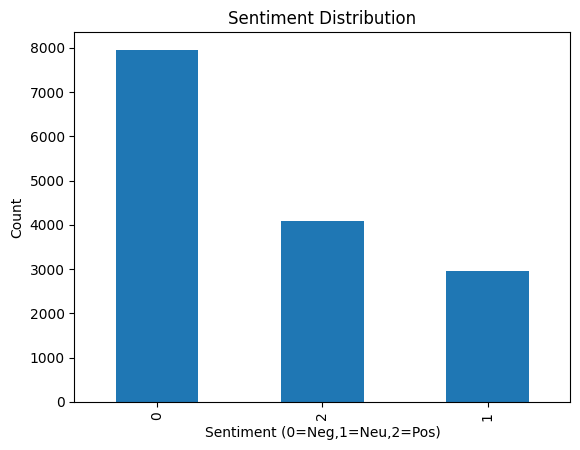

In [242]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Neg,1=Neu,2=Pos)")
plt.ylabel("Count")
plt.show()

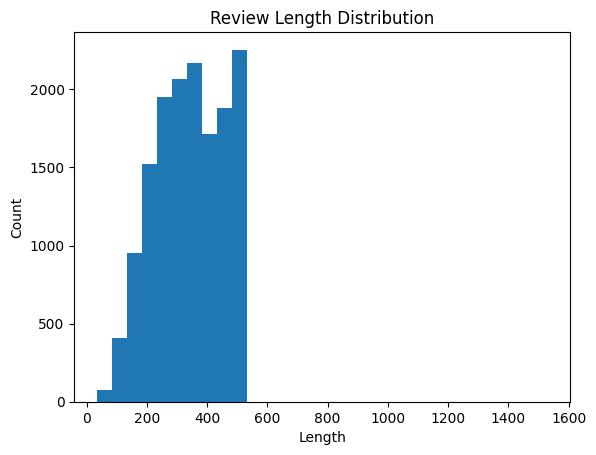

In [243]:
df['length'] = df['content'].apply(len)

plt.hist(df['length'], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

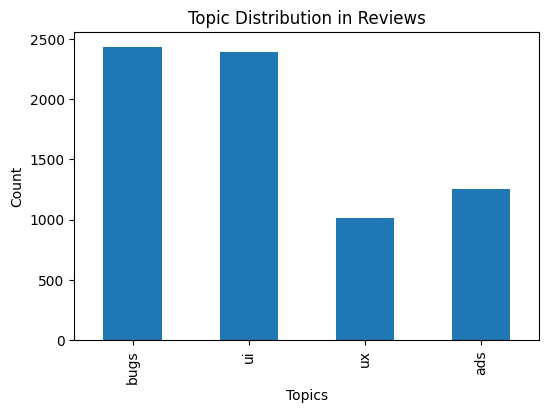

In [244]:
import matplotlib.pyplot as plt

topic_counts = df[['bugs','ui','ux','ads']].sum()

plt.figure(figsize=(6,4))
topic_counts.plot(kind='bar')

plt.title("Topic Distribution in Reviews")
plt.xlabel("Topics")
plt.ylabel("Count")

plt.show()

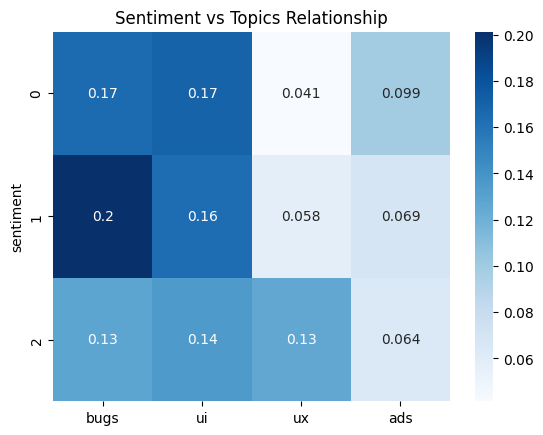

In [245]:
import seaborn as sns

topic_sent = df.groupby('sentiment')[['bugs','ui','ux','ads']].mean()

sns.heatmap(topic_sent, annot=True, cmap="Blues")
plt.title("Sentiment vs Topics Relationship")
plt.show()

#***LABELS DISTRIBUTION (TWO OUTPUT SENTIMENT AND TOPIC)***

In [246]:
y_sent = df['sentiment']
print(y_sent)

0        1
1        2
2        2
3        1
4        2
        ..
14995    2
14996    1
14997    2
14998    2
14999    2
Name: sentiment, Length: 15000, dtype: int64


In [247]:
import numpy as np
y_topic = np.array(df['topic_multi'].tolist())
print(y_topic)

[[1 0 0 0]
 [0 0 0 0]
 [0 1 0 1]
 ...
 [0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]]


# ***Feature Engineering***

In [287]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['content'])

sequences = tokenizer.texts_to_sequences(df['content'])
X = pad_sequences(sequences, maxlen=150)
print(X)

[[   0    0    0 ...   80  117  376]
 [   0    0    0 ...  774    2  290]
 [   0    0    0 ...   68   20   31]
 ...
 [   0    0    0 ...   19  324 5210]
 [   0    0    0 ...  107   10 1316]
 [   0    0    0 ...  183 1739 2264]]


# ***TRAIN TEST SPILT***

In [249]:
X_train, X_test, y_sent_train, y_sent_test, y_topic_train, y_topic_test = train_test_split(
    X, y_sent, y_topic, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("y_train:", y_sent_train.shape)
print("y_train:", y_topic_train.shape)

X_train: (12000, 150)
y_train: (12000,)
y_train: (12000, 4)


#***ANN LAYER AND EMBENDDING***

In [250]:
input_layer = Input(shape=(150,))

x = Embedding(input_dim=10000, output_dim=128)(input_layer)
x = GlobalAveragePooling1D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

sentiment_output = Dense(3, activation='softmax', name='sentiment')(x)
topic_output = Dense(4, activation='sigmoid', name='topic')(x)

model = Model(inputs=input_layer, outputs=[sentiment_output, topic_output])

#***MODEL COMPILATION***

In [278]:
model.compile(
    optimizer='adam',
    loss={
        'sentiment': 'sparse_categorical_crossentropy',
        'topic': 'binary_crossentropy'
    },
    loss_weights={
        'sentiment': 1.0,
        'topic': 2.0
    },
    metrics={
        'sentiment': 'accuracy',
        'topic': 'accuracy'
    }
)

#***MODEL TRAINING***

In [279]:
model.fit(
    X_train,
    {'sentiment': y_sent_train, 'topic': y_topic_train},
    epochs=10,
    batch_size=32,
    validation_data=(X_test, {'sentiment': y_sent_test, 'topic': y_topic_test})
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - loss: 0.2447 - sentiment_accuracy: 0.9173 - sentiment_loss: 0.2211 - topic_accuracy: 0.7207 - topic_loss: 0.0118 - val_loss: 1.6835 - val_sentiment_accuracy: 0.7040 - val_sentiment_loss: 1.4103 - val_topic_accuracy: 0.6777 - val_topic_loss: 0.1365
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 0.2394 - sentiment_accuracy: 0.9194 - sentiment_loss: 0.2133 - topic_accuracy: 0.6879 - topic_loss: 0.0130 - val_loss: 1.2647 - val_sentiment_accuracy: 0.7320 - val_sentiment_loss: 1.1747 - val_topic_accuracy: 0.8697 - val_topic_loss: 0.0448
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.2172 - sentiment_accuracy: 0.9328 - sentiment_loss: 0.1874 - topic_accuracy: 0.6873 - topic_loss: 0.0149 - val_loss: 1.6183 - val_sentiment_accuracy: 0.7350 - val_sentiment_loss: 1.5317 - val_topic_accuracy: 0.6237 - val_topic_loss: 0.0435
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.1813 - sentiment_accuracy

#***MODEL TESTING***

In [280]:
pred_sent, pred_topic = model.predict(X_test)
sentiment = np.array(pred_sent)
sentiment = pred_sent.argmax(axis=1)
topics = (pred_topic > 0.4).astype(int)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


#***MODEL EVALUATION***

In [281]:
results = model.evaluate(
    X_test,
    {
        'sentiment': y_sent_test,
        'topic': y_topic_test
    },
    verbose=1
)

print(results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.6928 - sentiment_accuracy: 0.7290 - sentiment_loss: 1.5969 - topic_accuracy: 0.6757 - topic_loss: 0.0483
[1.6927763223648071, 1.5968893766403198, 0.04826711490750313, 0.7289999723434448, 0.6756666898727417]


# ***PREPROCESSING FOR USER INPUT***

In [283]:
import re
from textblob import TextBlob

def clean_input(text):
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # spelling correction
    text = str(TextBlob(text).correct())

    return text


#***PREDICT METHOD***

In [284]:
def predict_review(text, model, tokenizer, maxlen=150):
    import numpy as np
    import re

    text = preprocess(text)

    # convert to sequence
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=maxlen)

    # prediction
    pred_sent, pred_topic = model.predict(padded)

    # sentiment
    sent_index = np.argmax(pred_sent, axis=1)[0]

    sentiment_map = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }

    sentiment = sentiment_map[sent_index]

    # topics
    topic_labels = ["bugs", "ui", "ux", "ads"]
    topic_pred = (pred_topic > 0.3).astype(int)[0]

    topics = [topic_labels[i] for i in range(len(topic_labels)) if topic_pred[i] == 1]

    return sentiment, topics

#***APPLYING ON RAW INPUT***

In [286]:

text = "App crashes frequently and too many ads"
text1 = "App crashes every time I open it and too many ads"
text2 = "Very smooth and easy to use, nice experience"
text3 = "The interface looks okay but nothing special"

sentiment, topics = predict_review(text, model, tokenizer)
sentiment1, topics1 = predict_review(text1, model, tokenizer)
sentiment2, topics2 = predict_review(text2, model, tokenizer)
sentiment3, topics3 = predict_review(text3, model, tokenizer)

print("Sentiment:", sentiment, "Topics:", topics)
print("Sentiment:", sentiment1, "Topics:", topics1)
print("Sentiment:", sentiment2, "Topics:", topics2)
print("Sentiment:", sentiment3, "Topics:", topics3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Sentiment: Negative Topics: ['bugs', 'ads']
Sentiment: Negative Topics: ['bugs', 'ads']
Sentiment: Positive Topics: ['ux']
Sentiment: Neutral Topics: ['ui']
